In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
from tensorflow.keras.layers import Dense, LSTM, Input, Multiply
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import GMM
from MoE import dataset_prepare, MoE_model, test_set_eval

In [2]:
import matplotlib.pyplot as plt

In [3]:
def set_global_determinism(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
set_global_determinism(seed=42)

In [4]:
# Import Data
SPdata = pd.read_pickle('PreparedData/sp500_scaled_features.pkl')
SPdata.head(5)

,RR,VCR,VIXD,TBRD,OASD
Date,,,,,
2005-01-04,-0.981180,0.705810,-0.051754,1.180127,-0.806435
2005-01-05,-0.321860,0.055394,0.056137,-0.099518,0.627078
2005-01-06,0.258445,-0.558024,-0.262398,-0.080974,0.447889
2005-01-07,-0.142726,-0.325503,-0.046617,0.252848,-0.179273
2005-01-10,0.251710,0.044955,-0.133957,-0.118062,0.268700


In [5]:
# Split Dataset
X_train = tf.cast(SPdata[:'2021-12-31'], dtype = tf.float32)
X_CV = tf.cast(SPdata['2022-01-01':'2023-12-31'], dtype = tf.float32)
X_test = tf.cast(SPdata['2024-01-01':], dtype = tf.float32)

# Y
Y_train_binary = tf.where(X_train[:, 0] > 0, 1.0, 0.0)
Y_CV_binary = tf.where(X_CV[:, 0] > 0, 1.0, 0.0)
Y_test_binary = tf.where(X_test[:, 0] > 0, 1.0, 0.0)

In [6]:
K = 4
print("K-Means Initialization...") # hot-start on GMM
kmeans = GMM.TF_kmeans(K)
mu_init, pi_init, sigma_init = kmeans.gmm_init_params(X_train)

print("Running GMM Training...")
gmm = GMM.TF_GMM(K, max_iters=150, tol=1e-4)
gamma_train, log_likelihood, aic, bic = gmm.fit(X_train, mu_init, pi_init, sigma_init, verbose=True)
Mu, Sigma, Pi = gmm.mu, gmm.sigma, gmm.pi

K-Means Initialization...
Running GMM Training...
---GMM training---
Iteration:   0 | Log_likelihood: -23064.3359 | Shift: inf
Iteration:   5 | Log_likelihood: -21502.3477 | Shift: 90.398438
Iteration:  10 | Log_likelihood: -21166.6992 | Shift: 40.777344
Iteration:  15 | Log_likelihood: -21092.5957 | Shift: 7.162109
Iteration:  20 | Log_likelihood: -21058.0117 | Shift: 6.679688
Iteration:  25 | Log_likelihood: -21038.0273 | Shift: 2.613281
Iteration:  30 | Log_likelihood: -21030.2793 | Shift: 1.099609
Iteration:  35 | Log_likelihood: -21025.8086 | Shift: 0.839844
Iteration:  40 | Log_likelihood: -21021.4355 | Shift: 0.912109
Iteration:  45 | Log_likelihood: -21016.8906 | Shift: 0.849609
Iteration:  50 | Log_likelihood: -21014.0625 | Shift: 0.339844
Iteration:  55 | Log_likelihood: -21013.4121 | Shift: 0.048828
Iteration:  60 | Log_likelihood: -21013.3203 | Shift: 0.007812
Iteration:  65 | Log_likelihood: -21013.3086 | Shift: 0.000000
---Iteration end at 65.---

--- Model Metrics ---
To

In [7]:
# calculate gamma_CV, gamma_test under K = 4.
gamma_CV, log_likelihood_cv = GMM.GMM_predict(X_CV, Mu, Sigma, Pi)
gamma_test, log_likelihood_test = GMM.GMM_predict(X_test, Mu, Sigma, Pi)

### Tensorflow Data Pipeline

In [8]:
windowsize = 10
batch_size = 32
train_ts_set = tf.keras.utils.timeseries_dataset_from_array(
    data = X_train[:-1, :],
    targets = Y_train_binary[windowsize:],
    sequence_length = windowsize,
    batch_size = batch_size
)
gamma_train_aligned = gamma_train[windowsize-1:-1, :]
train_gamma_set = tf.data.Dataset.from_tensor_slices(gamma_train_aligned).batch(batch_size)

train_set = tf.data.Dataset.zip((train_ts_set, train_gamma_set)).map(
    lambda ts_and_y, g: (
        {"TimeSeries_Input": ts_and_y[0], "GMM_Gate_Input": g}, 
        ts_and_y[1]                                             
    )
)
CV_ts_set = tf.keras.utils.timeseries_dataset_from_array(
    data = X_CV[:-1, :],
    targets = Y_CV_binary[windowsize:],
    sequence_length = windowsize,
    batch_size = batch_size
)
gamma_CV_aligned = gamma_CV[windowsize-1: -1, :]
CV_gamma_set = tf.data.Dataset.from_tensor_slices(gamma_CV_aligned).batch(batch_size)

CV_set = tf.data.Dataset.zip((CV_ts_set, CV_gamma_set)).map(
    lambda ts_and_y, g: (
        {"TimeSeries_Input": ts_and_y[0], "GMM_Gate_Input": g}, 
        ts_and_y[1]                                             
    )
)

## MoE Model

In [9]:
tf.keras.backend.clear_session()

In [10]:
from tensorflow.keras import initializers
my_init = initializers.RandomNormal(mean=0.0, stddev=0.01, seed=3721)

num_features = 5

ts_input = Input(shape = (windowsize, num_features), name = 'TimeSeries_Input')
gate_input = Input(shape = (K,), name = 'GMM_Gate_Input')
expert_outputs = []

for i in range(K): 
    expert_lstm = LSTM(
        units=16, dropout = 0.3,
        kernel_initializer='glorot_uniform', 
        recurrent_initializer='orthogonal',  
        bias_initializer='zeros',
        activation='tanh', 
        kernel_regularizer=tf.keras.regularizers.l2(0.005), 
        name=f"Expert_{i}_LSTM"
    )(ts_input)
    
    expert_pred = Dense(units=1, activation='sigmoid', kernel_regularizer=tf.keras.regularizers.l2(0.0001), kernel_initializer= my_init, name=f"Expert_{i}_Output")(expert_lstm)
    
    expert_outputs.append(expert_pred)

merged_experts = tf.keras.layers.Concatenate(axis = -1, name = 'MergeExperts')(expert_outputs)

weighted_experts = Multiply(name="Gate_Multiply")([merged_experts, gate_input])

final_output = tf.keras.layers.Lambda(lambda x: tf.reduce_sum(x, axis=-1, keepdims=True), 
                      name="Final_Sum_Output")(weighted_experts)

model = tf.keras.models.Model(inputs=[ts_input, gate_input], outputs=final_output, name="MoE_SP500_Predictor")

model.summary()

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, 
    clipnorm=1.0), loss=tf.keras.losses.BinaryCrossentropy(), metrics=['accuracy'])

Model: "MoE_SP500_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ TimeSeries_Input    │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Expert_0_LSTM       │ (None, 16)        │      1,408 │ TimeSeries_Input… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Expert_1_LSTM       │ (None, 16)        │      1,408 │ TimeSeries_Input… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Expert_2_LSTM       │ (None, 16)        │      1,408 │ TimeSeries_Input… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Expert_3_LSTM       │ (None, 16)        │      1,408 │ TimeSeries_Input… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Expert_0_Output     │ (None, 1)         │         17 │ Expert_0_LSTM[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Expert_1_Output     │ (None, 1)         │         17 │ Expert_1_LSTM[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Expert_2_Output     │ (None, 1)         │         17 │ Expert_2_LSTM[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Expert_3_Output     │ (None, 1)         │         17 │ Expert_3_LSTM[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MergeExperts        │ (None, 4)         │          0 │ Expert_0_Output[… │
│ (Concatenate)       │                   │            │ Expert_1_Output[… │
│                     │                   │            │ Expert_2_Output[… │
│                     │                   │            │ Expert_3_Output[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ GMM_Gate_Input      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Gate_Multiply       │ (None, 4)         │          0 │ MergeExperts[0][… │
│ (Multiply)          │                   │            │ GMM_Gate_Input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Final_Sum_Output    │ (None, 1)         │          0 │ Gate_Multiply[0]… │
│ (Lambda)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,700 (22.27 KB)

 Trainable params: 5,700 (22.27 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_accuracy', 
    mode = 'max',
    patience=150, 
    restore_best_weights=True,
    start_from_epoch=25,
    verbose=1
)

In [12]:
class_weights = {0: 1.045, 1: 0.955}
history = model.fit(
    train_set, validation_data = CV_set, epochs = 200, 
    callbacks=[early_stopping],
    class_weight=class_weights, 
    verbose= 1
)

Epoch 1/200


134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5096 - loss: 0.7884 - val_accuracy: 0.4847 - val_loss: 0.7337
Epoch 2/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5253 - loss: 0.7110 - val_accuracy: 0.5031 - val_loss: 0.6998
Epoch 3/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5277 - loss: 0.6941 - val_accuracy: 0.5234 - val_loss: 0.6932
Epoch 4/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5256 - loss: 0.6913 - val_accuracy: 0.5255 - val_loss: 0.6922
Epoch 5/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5258 - loss: 0.6909 - val_accuracy: 0.5214 - val_loss: 0.6921
Epoch 6/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5270 - loss: 0.6908 - val_accuracy: 0.5255 - val_loss: 0.6920
Epoch 7/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5253 - loss: 0.6908 - val_accuracy: 0.5234 - val_loss: 0.6920
Epoch 8/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5256 - loss: 0.6908 - val_accuracy: 0.5193

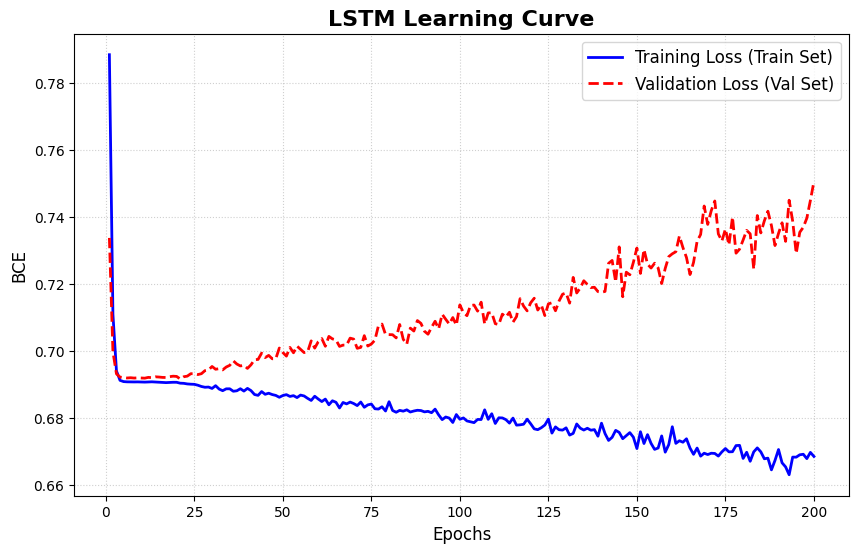

In [13]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, training_loss, 'b-', linewidth=2, label='Training Loss (Train Set)')
plt.plot(epochs_range, validation_loss, 'r--', linewidth=2, label='Validation Loss (Val Set)')

plt.title('LSTM Learning Curve', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('BCE', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [14]:
test_ts_set = tf.keras.utils.timeseries_dataset_from_array(
    data = X_test[:-1, :],
    targets = Y_test_binary[windowsize:],
    sequence_length = windowsize,
    batch_size = batch_size
)
gamma_test_aligned = gamma_test[windowsize - 1 : -1]
test_gamma_set = tf.data.Dataset.from_tensor_slices(gamma_test_aligned).batch(batch_size)

test_set = tf.data.Dataset.zip((test_ts_set, test_gamma_set)).map(
    lambda ts_and_y, g: (
        {"TimeSeries_Input": ts_and_y[0], "GMM_Gate_Input": g}, 
        ts_and_y[1]                                             
    )
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4990 - loss: 0.7159 

 Test set accuracy: 49.90%
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


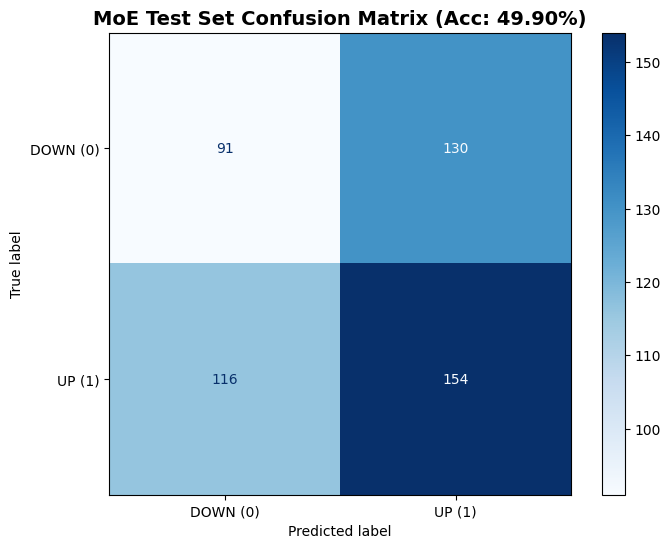


📊 Classification Report:
              precision    recall  f1-score   support

    DOWN (0)       0.44      0.41      0.43       221
      UP (1)       0.54      0.57      0.56       270

    accuracy                           0.50       491
   macro avg       0.49      0.49      0.49       491
weighted avg       0.50      0.50      0.50       491



In [15]:
test_loss, test_acc = model.evaluate(test_set, verbose=1)
print(f"\n Test set accuracy: {test_acc * 100:.2f}%")

pred_probs = model.predict(test_set)
pred_classes = (pred_probs > 0.5).astype(int).flatten()

true_labels = []
for _, y in test_set:
    true_labels.extend(y.numpy())
true_labels = np.array(true_labels).flatten()

cm = confusion_matrix(true_labels, pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['DOWN (0)', 'UP (1)'])


fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d') 

plt.title(f'MoE Test Set Confusion Matrix (Acc: {test_acc*100:.2f}%)', fontsize=14, fontweight='bold')
plt.show()

print("\n📊 Classification Report:")
print(classification_report(true_labels, pred_classes, target_names=['DOWN (0)', 'UP (1)']))

## Grid Research

In [8]:
window_size = [5, 10, 20, 60]
batch_size = 32

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_accuracy', 
    mode = 'max',
    patience=150, 
    restore_best_weights=True,
    start_from_epoch=25,
    verbose=1
)

In [ ]:
result_dic = {} # Restore MoE models under Different window_size.
best_window = None
best_val_acc = 0.0
for ws in window_size:
    print(f'Start Trainning on window size: {ws}.')
    tf.keras.backend.clear_session()
    train_set_ws = dataset_prepare(X_train, Y_train_binary, gamma_train, ws, batch_size= 32)
    CV_set_ws = dataset_prepare(X_CV, Y_CV_binary, gamma_CV, ws, batch_size= 32)
    model_dic = {} # Restore the single MoE models
    model = MoE_model(ws, 5, K, 16)

    # Minimize the BinaryCrossEntropy of CV set
    history= model.fit(train_set_ws, validation_data = CV_set_ws, epochs = 150, callbacks = [early_stopping], verbose = 0)


    # Best window size
    final_model_acc = max(history.history['val_accuracy'])
    print(f"Window size at: {ws}, Best Accuracy: {final_model_acc * 100:.2f}%")

    if final_model_acc > best_val_acc:
        best_val_acc = final_model_acc
        best_window = ws

    # Restore the training result
    model_dic['model'] = model
    model_dic['history'] = history
    model_dic['best_ACC'] = final_model_acc
    result_dic[ws] = model_dic

print(f"Grid Research End. \nBest Winodw Size: {best_window}, CV set accuracy: {best_val_acc * 100:.2f}%")

Start Trainning on window size: 5.
Epoch 187: early stopping
Restoring model weights from the end of the best epoch: 87.
Window size at: 5, Best Accuracy: 51.01%
Start Trainning on window size: 10.
Epoch 110: early stopping
Restoring model weights from the end of the best epoch: 11.
Window size at: 10, Best Accuracy: 50.10%
Start Trainning on window size: 20.
Epoch 110: early stopping
Restoring model weights from the end of the best epoch: 11.
Window size at: 20, Best Accuracy: 50.31%
Start Trainning on window size: 60.
Restoring model weights from the end of the best epoch: 197.
Window size at: 60, Best Accuracy: 52.38%
Grid Research End. 
Best Winodw Size: 60, CV set accuracy: 52.38%


In [ ]:
model_best = result_dic[best_window]['model']
test_set_ws = dataset_prepare(X_CV, Y_CV_binary, gamma_CV, best_window, batch_size= 32)
test_set_eval(model_best, test_set_ws)